# Milestone 3: EDA, Planning, and Setting Goals

Project Group 2: Max Bahar, Mila Ivanovska, Stefan Chu, Ted McCulloch


In [1]:
# imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# utilities
import utils.preprocessing as pp
import utils.visualization as viz

## Data Description

Our final data frame consists of data from:

1. Historical State information - collected from spacetrack on the 1st and 15th of each moth ranging from 03/15/2023 to 03/15/2025 (*)

2. Satellite catalog (satcat) information - descriptive information about a satellite.

3. Calculated additional values - semi-major axis, apogee, perigee, and orbital regime need to be calculated using state information.

(*) Note: Previously our [DataAcquisition.ipynb](https://github.com/tedinspace/space-object-identification/blob/main/src/DataAcquisition.ipynb) notebook had the date range from '2023-03-15' to '2024-03-15', which was mentioned in our M2 comments. This is because the spacetrack api has a limited number of calls you can make per hour, so Ted broke up the calls into two runs (one per year). Realistically, you should be able to run this number of calls without a problem, but Space-Track had already issued a warning to Ted while he was making test calls. They are known to delete accounts that break too many api rules; Ted should know.

In [2]:
# load our data
satCat_current = pd.DataFrame(pp.loadUnprocessedSatCat_current("../data/satcat.zip")).set_index("NORAD_CAT_ID")
satCat_decayed = pd.DataFrame(pp.loadUnprocessedSatCat_decayed("../data/satcat.zip")).set_index("NORAD_CAT_ID")
snapshot_states = pp.loadSeveralYearsOfUnprocessedStates(["../data/snapshots_2023.zip","../data/snapshots_2024_p1.zip","../data/snapshots_2024_p2.zip","../data/snapshots_2025.zip"])
aggregatedData, uncataloged_states, nDuplicatesFound = pp.deduplicateAndMergeDataSources(snapshot_states, satCat_current, satCat_decayed)

# display shape of data
df = pd.DataFrame(aggregatedData)
df.shape

(1034009, 22)

<table>
    <tr>
        <th>Source</th> <th>Payload</th> <th>Debris + Rocket Bodies</th> <th>Analyst Objects</th> <th>TOTAL</th> 
    </tr>
    <tr>
        <td>Space-Track's login page</td> <td>11,400</td> <td>18,800</td> <td>17,500</td> <td>47,700</td> 
    </tr>
    <tr>
        <td>Our Space-Track snapshots</td> <td>15,145</td> <td>15,350 (12,999 + 2,351)</td> <td>818</td> <td>31,313</td> 
    </tr>
    <tr>
        <td>Our Space-Track snapshots (decayed objects removed)</td> <td>13,418</td> <td>13,614 (11,440 + 2,174)</td> <td>584</td> <td>27,616</td>
    </tr>
    <tr>
        <td>CelesTrak.org</td> <td>14,610 **</td> <td>15,611</td> <td>n/a</td> <td>33,158</td> 
    </tr>
</table>

** [Celestrak](https://celestrak.org/satcat/boxscore.php) has the active payload count at 11,614, which is closer but not identical to Space-Track. 


**Why Don't These Numbers Match?**

1. [Not all Space-Track accounts are the same.](https://www.space-track.org/myprofile#permissions) Some accounts have access to states that are not public; most of these fall under analyst objects, but could also include other object types.

2. [CelesTrak](https://celestrak.org/satcat/sources.php) compiles data from different countries--not only relying on Space-Track

3. When Space-Track says "payloads" on their landing page, they mean "active payloads," i.e., satellites that are still being flown/operated. Unfortunately, with this level of access, Space-Track doesn't indicate which objects are active and which are not. [The field "CURRENT" is always set to "Y" and never "N"](https://www.space-track.org/basicspacedata/query/class/satcat/CURRENT/N/emptyresult/show). Ideally, we would have the type categories of **PAYLOAD_ACTIVE** and **PAYLOAD_INACTIVE**, but that information is not readily available on unclassified systems. Inactive payloads are typically placed in [graveyard orbits](https://spaceplace.nasa.gov/spacecraft-graveyard/en/), which should make them distinguishable from debris and rocket bodies in our model.


**Aren't rocket bodies just debris?**

Technically, yes, but they are a specific type of debris. They are typically large and will likely respond to perturbations differently than small space-trash debris.


In [3]:
# create dataframe of objects
df_no_dup = df.drop_duplicates(subset="NUMBER", keep="first")

# display information on unique objects
print(f"{df_no_dup.shape[0]} unique objects")
print(df_no_dup['TYPE'].value_counts())
print('')

# display information on current unique objects
df_no_dup = df_no_dup[df_no_dup['IS_CURRENT']==1]
print(f"{df_no_dup.shape[0]} unique objects - not decayed")
print(df_no_dup['TYPE'].value_counts())

31313 unique objects
TYPE
PAYLOAD        15145
DEBRIS         12999
ROCKET BODY     2351
UNKNOWN          818
Name: count, dtype: int64

27616 unique objects - not decayed
TYPE
PAYLOAD        13418
DEBRIS         11440
ROCKET BODY     2174
UNKNOWN          584
Name: count, dtype: int64


In [4]:
# removing analyst objects 
df = df[df['TYPE'] != 'UNKNOWN']
df.reset_index(drop=True, inplace=True)
df.shape

(1011052, 22)

In [5]:
# defining the different variables in our dataset
response = 'TYPE'
X_exclude = ['NUMBER', 'NAME','RCS', 'IS_CURRENT', 'REGIME', 'EPOCH', 'COUNTRY', 'LINE1', 'LINE2']
X_numerical = ['INCL', 'RAAN', 'ECC', 'ARG_PER', 'MEAN_ANOM', 'MEAN_MOTION', 'SMA_KM','APOGEE_KM', 'PERIGEE_KM', 'MEAN_MOTION_1ST_DER', 'MEAN_MOTION_2ND_DER', 'B_STAR']
X_numerical2 = ['INCL', 'RAAN', 'ECC', 'ARG_PER', 'MEAN_MOTION', 'SMA_KM','APOGEE_KM', 'PERIGEE_KM', 'MEAN_MOTION_1ST_DER'] # no mean anom
X_numerical3 = ['INCL', 'RAAN', 'ECC', 'ARG_PER', 'MEAN_MOTION'] # no mean anom, sma km, apogee km, perigee km, mean motion 1st der
column_names_map = viz.pretty_column_names()

In [6]:
# scale data for better performance with neural nets
scaler = StandardScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df[X_numerical]), columns=X_numerical)
df_scaled.reset_index(drop=True, inplace=True)
df_response = df[[response]]
df_response.reset_index(drop=True, inplace=True)
df_exc = df[X_exclude]
df_exc.reset_index(drop=True, inplace=True)
df_scaled = pd.concat([df_response, df_scaled, df_exc], axis=1)

# display the data
df_scaled.head(2)

,TYPE,INCL,RAAN,ECC,ARG_PER,MEAN_ANOM,MEAN_MOTION,SMA_KM,APOGEE_KM,PERIGEE_KM,...,B_STAR,NUMBER,NAME,RCS,IS_CURRENT,REGIME,EPOCH,COUNTRY,LINE1,LINE2
0,PAYLOAD,-1.196979,-1.313405,0.685616,1.243249,-1.344251,-0.153392,-0.274948,-0.208660,-0.323569,...,-0.109529,11,VANGUARD 2,MEDIUM,1,LEO,23227.529469,US,1 11U 59001A 23227.52946902 .00000437 0...,2 11 32.8786 39.4077 1461765 291.2012 53...
1,ROCKET BODY,-1.196343,0.862265,0.819142,-1.424497,1.452507,-0.246231,-0.255350,-0.176047,-0.323377,...,-0.101960,12,VANGUARD R/B,MEDIUM,1,LEO,23227.463430,US,1 12U 59001B 23227.46343039 .00000595 0...,2 12 32.8971 270.9551 1659905 26.7664 340...


## Summary of the Data


#### Acronyms to Watch Out For

<table>
  <tr>
    <th>Acronyms</th>  
    <th>Meaning</th>  
    <th>Details</th> 
</tr>
<tr>
    <td>TLE</td>  <td>Two-Line Element</td>  <td>How orbits are typically published; two 69 character length strings </td> 
</tr>
<tr>
    <td>LEO</td>  
    <td>Low Earth Orbit</td>  
    <td>Falls around 2,000 km above the Earth's surface.</td> 
</tr>
<tr>
    <td>MEO</td>  
    <td>Medium Earth Orbit</td>  
    <td>Falls between 2,000 and 35,786 km above the Earth's surface.</td> 
</tr>
<tr>
    <td>HEO</td>  
    <td>Highly Eccentric Orbit</td>  
    <td>These have high eccentricity, meaning they are elliptical in shape and have large disparities between their apogee and perigee.</td> 
</tr>
<tr>
    <td>GEO</td>  
    <td>Geostationary Orbit or Geosynchronous Orbit</td>  
    <td>These are around 35,786 km from the Earth's surface. "Geostationary" and "Geosynchronous" are used interchangeably, but strictly speaking, Geostationary orbits have low inclination and match the Earth's rotation almost exactly. Geosynchronous orbits expand the definition to include satellites with higher inclinations and less precise periods.</td> 
</tr>
    <tr>
    <td>RCS</td>  <td>Radar Cross Section</td>  <td>Formally it refers to the object's RADAR signature (how much energy an object reflects back at the RADAR), but informally refers to the size of the object. If the object is large (and not stealth), more energy will be reflected back at the RADAR</td> 
</tr>
<tr>
    <td>RAAN</td>  <td>The Right Ascension of the Ascending Node </td>  <td>One of the orbital elements;  longitude of the point where the spacecraft crosses the equatorial plane </td> 
</tr>
<tr>
    <td>SMA</td>  <td>semi-major axis</td>  <td>One of the orbital elements;  distance from the center of an orbit to the longer end of the orbit</td> 
</tr>
</table>

#### Description of Features

<table>
    <tr>
        <th>Include in Model</th> <th>Feature</th> <th>Data Type</th> <th>Units</th> <th>Description</th>
    </tr>
    <tr>
        <td style="background-color: red;">No</td> <td>NAME</td> <td>String</td> <td>-</td> <td>Name of satellite</td>
    </tr>
    <tr>
        <td style="background-color: red;">No</td> <td>NUMBER</td> <td>String</td> <td>-</td> <td>NORAD assigned RSO number</td>
    </tr>
    <tr>
        <td style="background-color: green;">Yes (Response)</td> <td>TYPE</td> <td>String/Enum</td> <td>-</td> <td>Type of object: payload, debris, rocket body</td>
    </tr>
    <tr>
        <td style="background-color: red;">No</td> <td>RCS</td> <td>String/Enum</td> <td>-</td> <td>Radar Cross Section - encoding of object size</td>
    </tr>
    <tr>
        <td style="background-color: red;">No</td> <td>IS_CURRENT</td> <td>Boolean</td> <td>-</td> <td>Whether or not the object has decayed since we started collecting catalog data. Note: The satellite catalog has a field called "CURRENT," which is not the same as this. We created this variable to track how many objects burned up in orbit (decayed) since our catalog start (3-15-2023). It is only accurate up until we stopped collecting data (3-15-2025).</td>
    </tr>
    <tr>
        <td style="background-color: red;">No</td> <td>REGIME</td> <td>String/Enum</td> <td>-</td> <td>Orbital regime of data</td>
    </tr>
    <tr>
        <td style="background-color: red;">No</td> <td>EPOCH</td> <td>Float</td> <td>Year/Day of Year/Fraction</td> <td>Validity time for state</td>
    </tr>
    <tr>
        <td style="background-color: green;">Yes</td> <td>INCL</td> <td>Float</td> <td>Degree</td> <td>Orbit inclination</td>
    </tr>
    <tr>
        <td style="background-color: green;">Yes</td> <td>RAAN</td> <td>Float</td> <td>Degree</td> <td>Right Ascension of the Ascending Node - longitude of the point where the spacecraft crosses the equatorial plane</td>
    </tr>
    <tr>
        <td style="background-color: green;">Yes</td> <td>ECC</td> <td>Float</td> <td>[0,1]</td> <td>Eccentricity - measure of how circular or elliptical an orbit is</td>
    </tr>
    <tr>
        <td style="background-color: green;">Yes</td> <td>ARG_PER</td> <td>Float</td> <td>Degree</td> <td>Argument of perigee - rotation/orientation of orbit</td>
    </tr>
    <tr>
        <td style="background-color: red;">No</td> <td>MEAN_ANOM</td> <td>Float</td> <td>Degree</td> <td>Mean anomaly - where the object is at epoch in orbit</td>
    </tr>
    <tr>
        <td style="background-color: green;">Yes</td> <td>MEAN_MOTION</td> <td>Float</td> <td>Rev/Day</td> <td>Revolutions per day given orbit</td>
    </tr>
    <tr>
        <td style="background-color: green;">Yes</td> <td>SMA_KM</td> <td>Float</td> <td>KM</td> <td>Semi-major axis - the distance from the center of an ellipse to the longer end of the ellipse</td>
    </tr>
    <tr>
        <td style="background-color: orange;">Maybe</td> <td>APOGEE_KM</td> <td>Float</td> <td>KM</td> <td>Furthest orbit gets from Earth</td>
    </tr>
    <tr>
        <td style="background-color: orange;">Maybe</td> <td>PERIGEE_KM</td> <td>Float</td> <td>KM</td> <td>Closest orbit gets from Earth</td>
    </tr>
    <tr>
        <td style="background-color: green;">Yes</td> <td>MEAN_MOTION_1ST_DER</td> <td>Float</td> <td>Rev/Day<sup>2</sup></td> <td>Ballistic coefficient measure</td>
    </tr>
    <tr>
        <td style="background-color: red;">No</td> <td>COUNTRY</td> <td>String</td> <td>-</td> <td>Country code pulled from Satellite Catalog</td>
    </tr>
    <tr>
        <td style="background-color: red;">No</td> <td>LINE1</td> <td>String</td> <td>-</td> <td>First line of TLE</td>
    </tr>
    <tr>
        <td style="background-color: red;">No</td> <td>LINE2</td> <td>String</td> <td>-</td> <td>Second line of TLE</td>
    </tr>
</table>


In [7]:
# preview of unscaled data
df.head(2)

,NUMBER,NAME,TYPE,RCS,IS_CURRENT,REGIME,EPOCH,INCL,RAAN,ECC,...,MEAN_MOTION,SMA_KM,APOGEE_KM,PERIGEE_KM,MEAN_MOTION_1ST_DER,MEAN_MOTION_2ND_DER,B_STAR,COUNTRY,LINE1,LINE2
0,11,VANGUARD 2,PAYLOAD,MEDIUM,1,LEO,23227.529469,32.8786,39.4077,0.146176,...,11.872714,8116.494528,2924.83529,551.953765,0.000004,0.0,0.000214,US,1 11U 59001A 23227.52946902 .00000437 0...,2 11 32.8786 39.4077 1461765 291.2012 53...
1,12,VANGUARD R/B,ROCKET BODY,MEDIUM,1,LEO,23227.463430,32.8971,270.9551,0.165991,...,11.457434,8311.452812,3312.97502,553.730604,0.000006,0.0,0.000354,US,1 12U 59001B 23227.46343039 .00000595 0...,2 12 32.8971 270.9551 1659905 26.7664 340...


In [8]:
# describe unscaled data
df.describe()

,IS_CURRENT,EPOCH,INCL,RAAN,ECC,ARG_PER,MEAN_ANOM,MEAN_MOTION,SMA_KM,APOGEE_KM,PERIGEE_KM,MEAN_MOTION_1ST_DER,MEAN_MOTION_2ND_DER,B_STAR
count,1.011052e+06,1.011052e+06,1.011052e+06,1.011052e+06,1.011052e+06,1.011052e+06,1.011052e+06,1.011052e+06,1.011052e+06,1.011052e+06,1.011052e+06,1.011052e+06,1.011052e+06,1.011052e+06
mean,9.295101e-01,2.394033e+04,6.769199e+01,1.791879e+02,4.443714e-02,1.679667e+02,1.918668e+02,1.255885e+01,1.085167e+04,5.408207e+03,3.538930e+03,9.569788e-05,5.745240e-06,2.234457e-03
std,2.559710e-01,6.208343e+02,2.908439e+01,1.064258e+02,1.483912e-01,9.912299e+01,1.026505e+02,4.473118e+00,9.947967e+03,1.190155e+04,9.231346e+03,2.851011e-03,7.594689e-04,1.844516e-02
min,0.000000e+00,2.307400e+04,3.000000e-04,2.000000e-04,1.000000e-06,1.800000e-03,1.000000e-04,3.183586e-02,6.486968e+03,1.225964e+02,7.893477e+01,-5.779533e-02,-4.489100e-05,0.000000e+00
25%,1.000000e+00,2.327437e+04,5.305310e+01,8.530457e+01,1.819000e-04,8.704080e+01,9.466045e+01,1.313470e+01,6.925375e+03,5.484600e+02,5.391871e+02,4.300000e-07,0.000000e+00,7.981700e-05
50%,1.000000e+00,2.409250e+04,7.145945e+01,1.761789e+02,1.527800e-03,1.480048e+02,2.139979e+02,1.433189e+01,7.159229e+03,8.266858e+02,6.785810e+02,1.052000e-05,0.000000e+00,3.717600e-04
75%,1.000000e+00,2.427532e+04,9.759410e+01,2.738752e+02,8.646425e-03,2.630657e+02,2.744034e+02,1.506391e+01,7.587902e+03,1.336963e+03,9.559758e+02,6.325000e-05,0.000000e+00,1.322100e-03
max,1.000000e+00,2.507500e+04,1.527004e+02,3.600000e+02,9.650900e-01,3.599992e+02,3.600000e+02,1.661652e+01,4.205240e+05,5.395501e+05,2.887417e+05,1.000000e+00,4.406700e-01,3.554100e+00


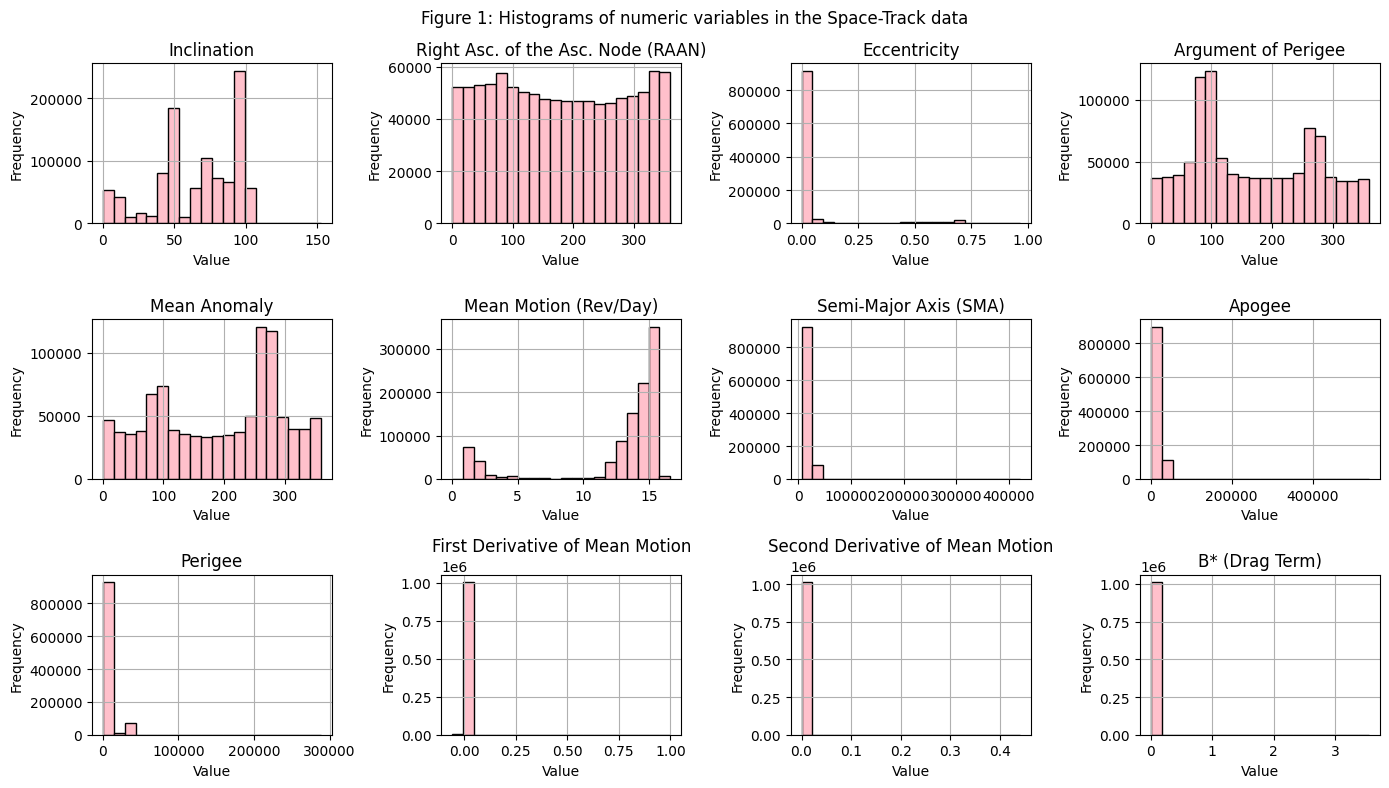

In [9]:
# plot histograms of numeric data
viz.plot_histograms(df, X_numerical, column_names_map, "Figure 1: Histograms of numeric variables in the Space-Track data")


Figure 1: demonstrates the distributions of our numerical variables as requested

## Data Analysis 


### Correlation between Elements

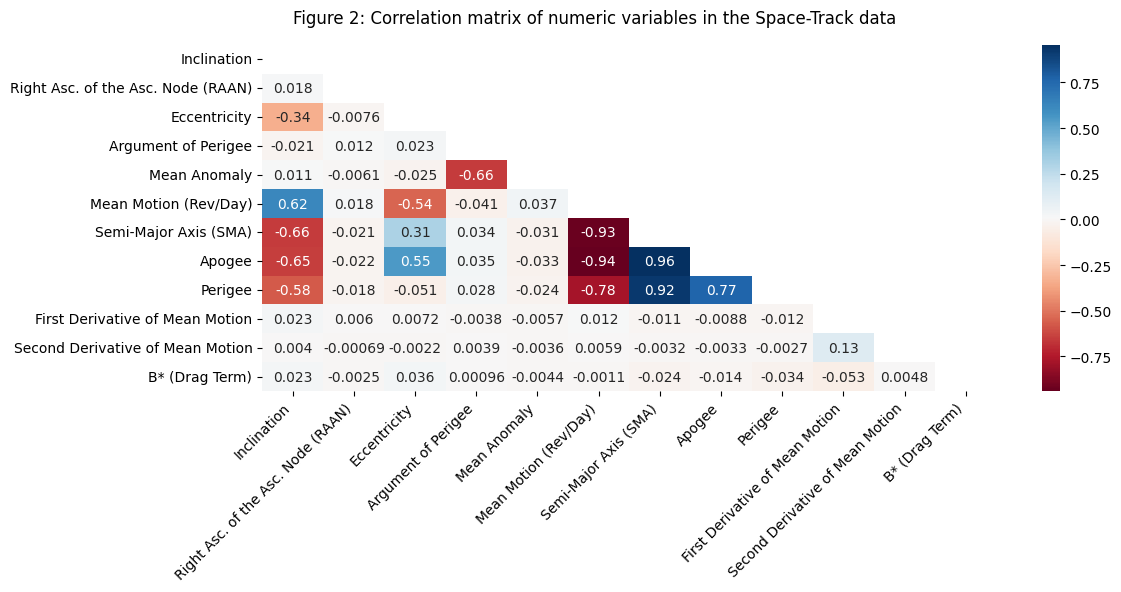

In [10]:
# plot a correlation matrix
viz.plot_corr_matrix(df_scaled, X_numerical, column_names_map, "Figure 2: Correlation matrix of numeric variables in the Space-Track data")

##### Patterns Discovered in Correlation Matrix

<table>
    <tbody>
        <tr>
            <th>Pattern A</th>
            <td>Circular orbits tend to have higher inclinations than elliptical orbits.</td>
        </tr>
        <tr>
            <th>Pattern B</th>
            <td>Lower Earth orbits are more likely to be more inclined than higher Earth orbits.</td>
        </tr>
        <tr>
            <th>Pattern C</th>
            <td>Lower Earth orbits tend to be more circular (lower eccentricity), while higher Earth orbits tend to be more elliptical (higher eccentricity).</td>
        </tr>
        <tr>
            <th>Trivial</th>
            <td>Trivial comparisons amount to saying "larger orbits will be larger" or "smaller orbits will be smaller."</td>
        </tr>
    </tbody>
</table>

<p>These patterns are consistent with our understanding of orbital dynamics, and they hold between object types.</p>


<table>
    <tbody>
        <tr>
            <th>Values</th>
            <th>Correlation</th>
            <th>Pattern</th>
            <th>Explanation</th>
        </tr>
        <tr>
            <th>Eccentricity vs. Inclination</th>
            <td>Slight Negative</td>
            <td>A</td>
            <td>Eccentricity describes the shape of an orbit: small values indicate a more circular orbit, while large values indicate a more elliptical one. A negative correlation suggests that orbits with higher inclination tend to be more circular in shape (lower eccentricity), while orbits with lower inclinations tend to be more elliptical (higher eccentricity).</td>
        </tr>
        <tr>
            <th>Mean Motion vs. Inclination</th>
            <td>Positive</td>
            <td>B</td>
            <td>Mean motion refers to the number of times an object completes a rotation per day. Larger values indicate lower Earth orbits (which have more rotations per day). A positive correlation with inclination suggests that lower Earth orbits are more likely to be inclined, while higher Earth orbits are less likely to be inclined.</td>
        </tr>
        <tr>
            <th>Semi-major Axis vs. Inclination</th>
            <td>Negative</td>
            <td>B</td>
            <td>The semi-major axis represents the longest semi-diameter of an orbit. Smaller values correspond to orbits closer to Earth. A negative correlation with inclination indicates that lower Earth orbits are more likely to be inclined, while higher Earth orbits are less likely to be inclined.</td>
        </tr>
        <tr>
            <th>Apogee vs. Inclination</th>
            <td>Negative</td>
            <td>B</td>
            <td>Apogee refers to the furthest point an object reaches from Earth in its orbit. A negative correlation with inclination indicates that lower Earth orbits are more likely to be inclined, while higher Earth orbits are less likely to be inclined.</td>
        </tr>
        <tr>
            <th>Perigee vs. Inclination</th>
            <td>Negative</td>
            <td>B</td>
            <td>Perigee is the closest point an object reaches to Earth in its orbit. A negative correlation with inclination again suggests that lower Earth orbits are more likely to be inclined, while higher Earth orbits are less likely to be inclined.</td>
        </tr>
        <tr>
            <th>Mean Motion vs. Eccentricity</th>
            <td>Negative</td>
            <td>C</td>
            <td>A negative correlation with mean motion indicates that more circular orbits (i.e., orbits with eccentricity closer to zero) will have a higher mean motion, meaning they will be closer to Earth.</td>
        </tr>
        <tr>
            <th>Semi-major axis vs. Eccentricity</th>
            <td>Slight Positive</td>
            <td>C</td>
            <td>A positive correlation suggests higher Earth orbits tend to be more eccentric (less circular).</td>
        </tr>
        <tr>
            <th>Apogee vs. Eccentricity</th>
            <td>Positive</td>
            <td>C</td>
            <td>Orbits with higher apogees (furthest distance orbit goes from Earth) tend to be more eccentric (less circular).</td>
        </tr>
        <tr>
            <th>Mean Anomaly vs. Argument of Perigee</th>
            <td>Negative</td>
            <td>Likely Meaningless</td>
            <td>Mean anomaly is an angle that describes how much an orbit has been completed at a given time. Because of its connection to the epoch, we may want to drop it from our model. The argument of Perigee describes the orientation of the orbit in space. Mean anomaly is measured relative to the argument of perigee. Because mean anomaly is relative to when the orbit was epoched, we don't think that this correlation is meaningful. </td>
        </tr>
        <tr>
            <th>Semi-major axis vs. Mean Motion</th>
            <td>Very Strong Negative</td>
            <td>Trivial</td>
            <td>Large semi-major axis means higher Earth orbit, and small mean motion means lower Earth orbit, so a negative correlation is a given.</td>
        </tr>
        <tr>
            <th>Apogee vs. Mean Motion</th>
            <td>Very Strong Negative</td>
            <td>Trivial</td>
            <td>Large apogee means higher Earth orbit, and small mean motion means lower Earth orbit, so a negative correlation is a given.</td>
        </tr>
        <tr>
            <th>Perigee vs. Mean Motion</th>
            <td>Strong Negative</td>
            <td>Trivial</td>
            <td>Large perigee means higher Earth orbit, and small mean motion means lower Earth orbit, so a negative correlation is a given.</td>
        </tr>
        <tr>
            <th>Apogee vs. Semi-major axis</th>
            <td>Very Strong Positive</td>
            <td>Trivial</td>
            <td>Apogee is a subsection of the semi-major axis, so a positive correlation is a given.</td>
        </tr>
        <tr>
            <th>Perigee vs. Semi-major axis</th>
            <td>Very Strong Positive</td>
            <td>Trivial</td>
            <td>Both of these measure an orbit's size or distance from Earth, so a positive correlation is a given.</td>
        </tr>
        <tr>
            <th>Perigee vs. Apogee</th>
            <td>Strong Positive</td>
            <td>Trivial</td>
            <td>Both of these measure an orbit's size or distance from Earth, so a positive correlation is a given.</td>
        </tr>
    </tbody>
</table>


##### Conclusions

1. Apogee, perigee, and semi-major axis encode simlilar/overlapping concepts. Some combination of these features might need to be dropped.

2. Mean anomaly is relative to epoch time and doesn't describe an orbit's shape. We should consider dropping this feature in our model.

### Principal Component Analysis (PCA)

In [11]:
# PCA without the specified columns below
df_to_use = df_scaled
df_to_use = df_to_use.drop(columns=['TYPE','NUMBER', 'NAME', 'IS_CURRENT', 'REGIME', 'EPOCH', 'COUNTRY', 'LINE1', 'LINE2', 'MEAN_ANOM', 'RCS'])
pca = PCA(n_components=len(df_to_use.columns))  
pca_result = pca.fit_transform(df_to_use)

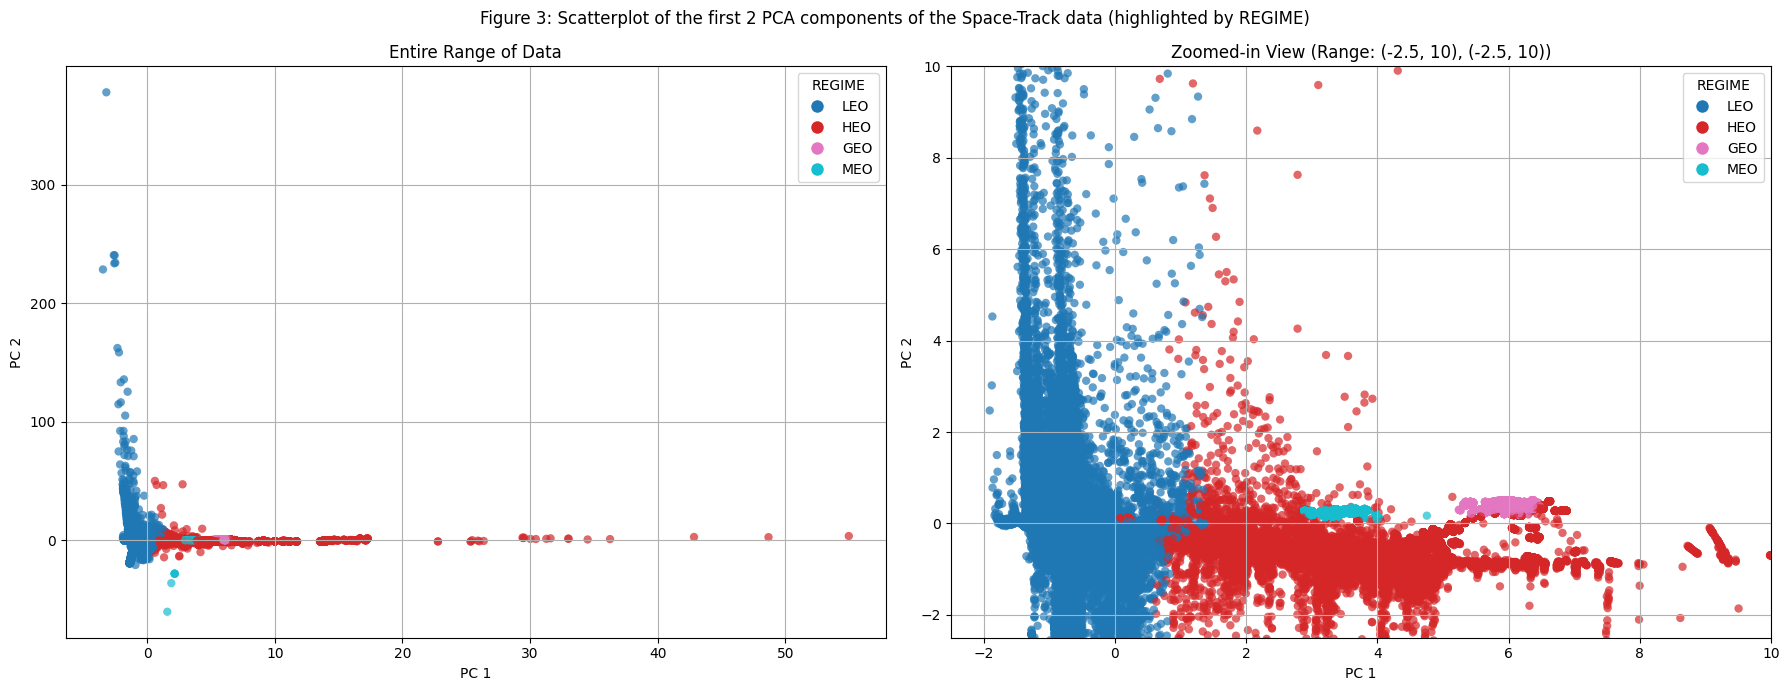

In [12]:
# visualize PCA results by regime
viz.pca_pc1_pc2_pair(pca_result, df_scaled["REGIME"], "REGIME", "Figure 3: Scatterplot of the first 2 PCA components of the Space-Track data (highlighted by REGIME)", x_range=(-2.5, 10), y_range=(-2.5, 10))

Figure 3 demonstrates that PCA effectively captures the distinctions between orbital regimes, resulting in well-defined clustering. LEO, GEO, and MEO are understandably well-clustered relative to each other, as their apogee and perigee values are of comparable magnitude—indicating relatively circular orbits. Consequently, these regimes occupy distinct regions of space. In contrast, HEO orbits can have significantly different apogee and perigee values, allowing them to span across multiple regimes. As a result, the HEO cluster overlaps with the other regimes and also extends into its own distinct region.

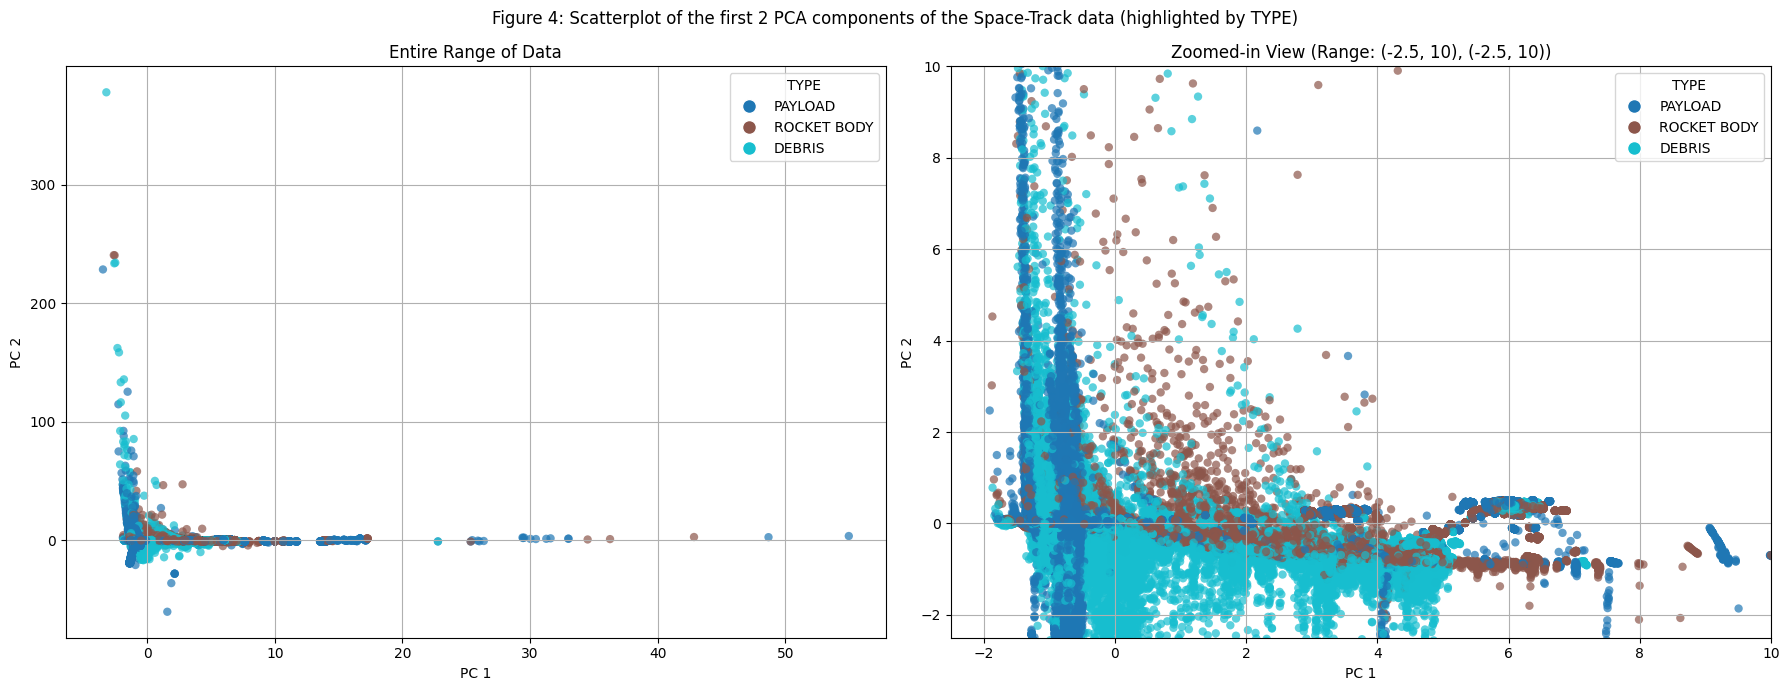

In [13]:
# visualize PCA results by type
viz.pca_pc1_pc2_pair(pca_result, df_scaled["TYPE"], "TYPE", "Figure 4: Scatterplot of the first 2 PCA components of the Space-Track data (highlighted by TYPE)", x_range=(-2.5, 10), y_range=(-2.5, 10))

Figure 4 presents our PCA plot colored by the response variable (TYPE) instead of orbital regime. While the clusters are no longer as distinct, there are still complex patterns visible for certain types. These patterns may be too nuanced for a basic model to capture effectively, but our neural network (NN) should be capable of learning and modeling them.

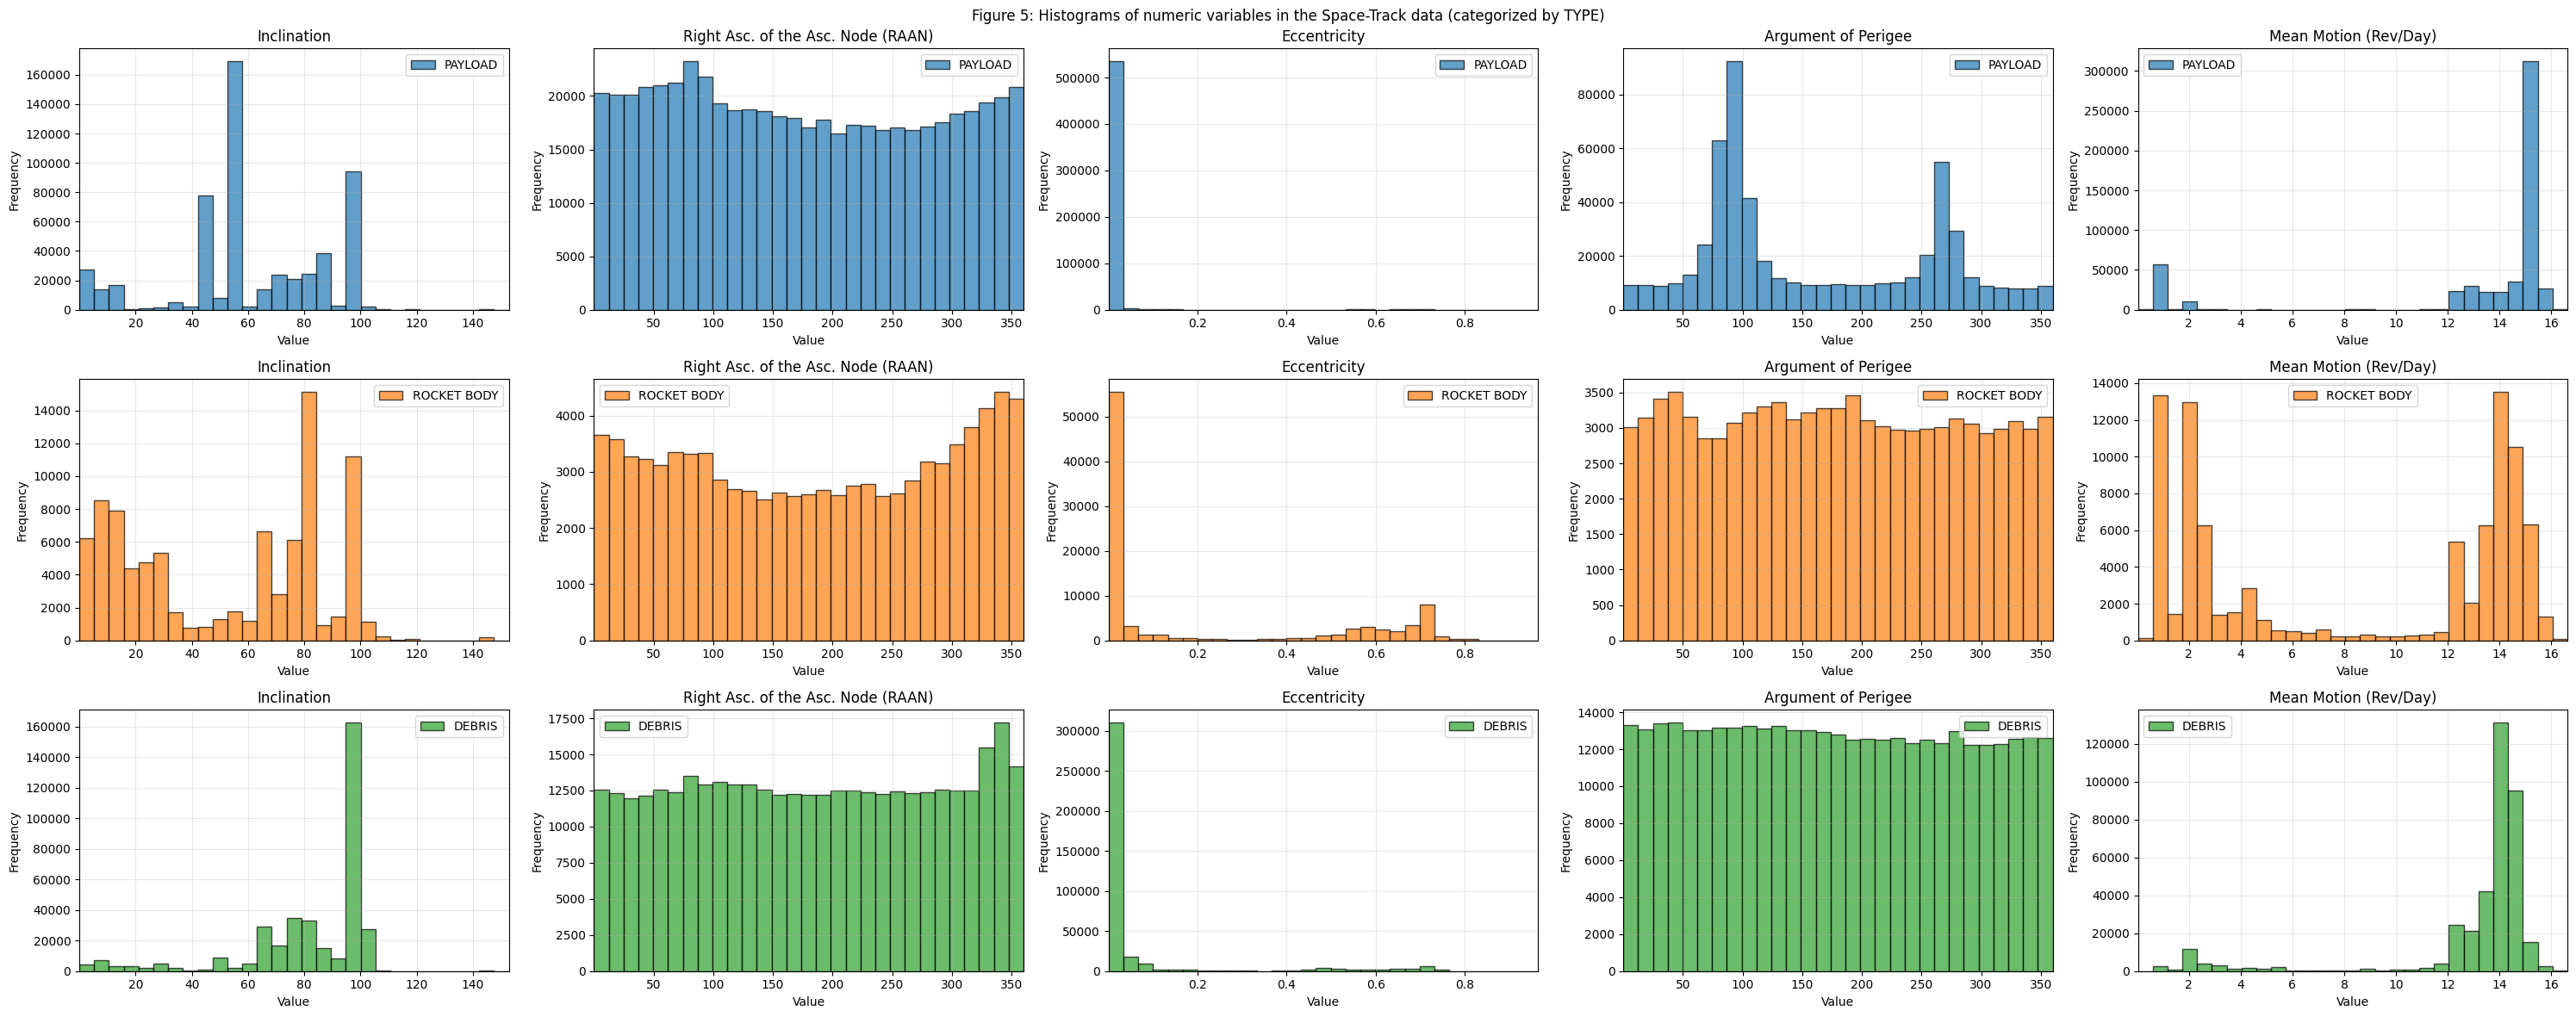

In [15]:
viz.plot_histograms_by_cat(df, X_numerical3, "TYPE", column_names_map, "Figure 5: Histograms of numeric variables in the Space-Track data (categorized by TYPE)")

Figure 5 illustrates some of the distributional differences and similarities among the various space object types. While Figure 1 shows that RAAN is uniformly distributed when aggregated across all data, Figure 5 reveals subtle variations across individual types. For instance, rocket bodies and debris are more likely to have highly eccentric orbits compared to payloads. The bimodal distribution of the argument of perigee is likely a result of station-keeping maneuvers—something that rocket bodies and debris typically do not perform. Additionally, mean motion can serve as a rough proxy for orbital regime, where the order from lowest to highest average mean motion is: GEO, MEO, HEO, and LEO. 

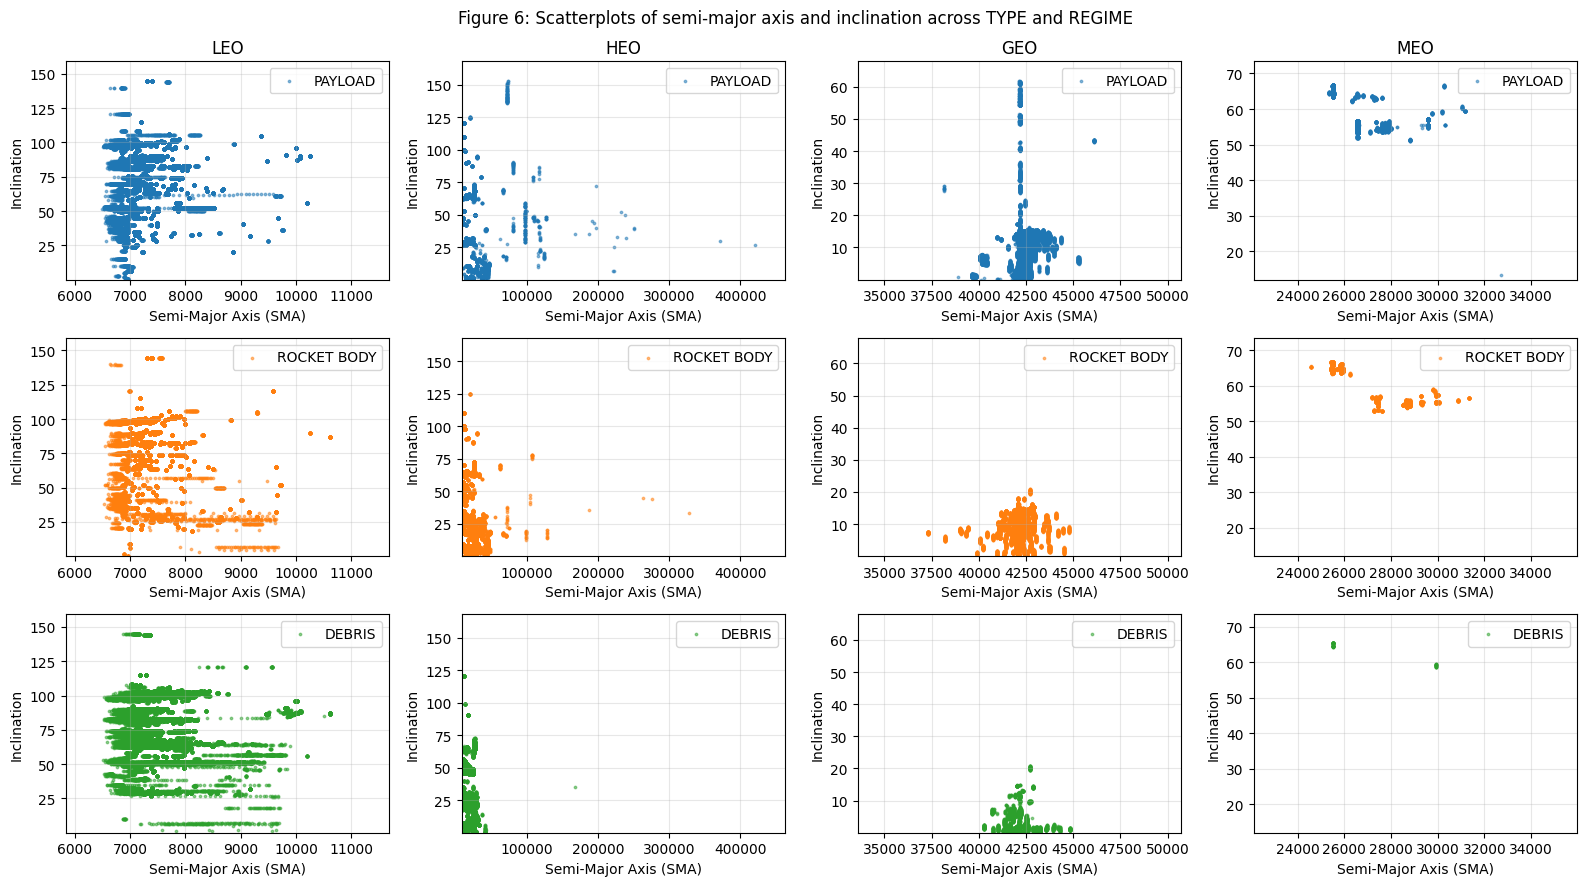

In [16]:
viz.plot_scatter_by_cat(df, "SMA_KM", "INCL", "REGIME", "TYPE", column_names_map, "Figure 6: Scatterplots of semi-major axis and inclination across TYPE and REGIME")

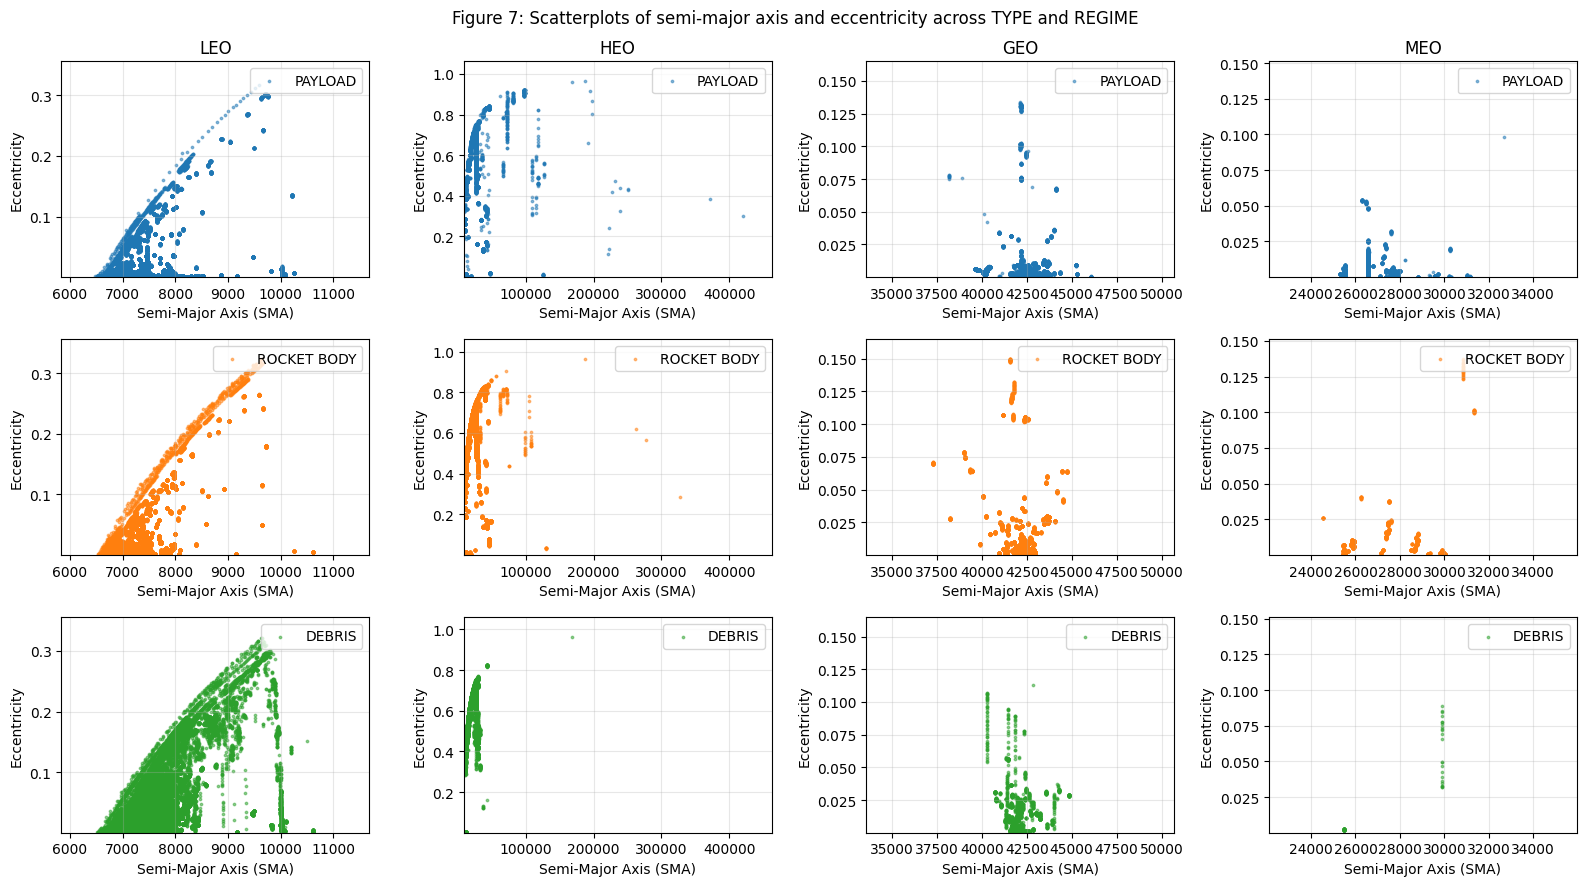

In [17]:
viz.plot_scatter_by_cat(df, "SMA_KM", "ECC", "REGIME", "TYPE", column_names_map, "Figure 7: Scatterplots of semi-major axis and eccentricity across TYPE and REGIME")

When comparing scatter plots by type alone, it can be difficult to identify meaningful patterns, as many of these may simply reflect differences in orbital regimes. However, by examining orbital elements while separating by both type and regime, this confounding factor can be mitigated. Figures 6 and 7 contain scatter plots that show relationships between variables identified in the correlation matrix from Figure 2. Their purpose is to demonstrate that objects of different types exhibit distinct patterns within the same regimes. For example, in figure 7, PAYLOAD and ROCKET states seem to have a positive, almost linear, relationship between eccentricity and semi-major axis (SMA). However, the relationship between these two variables for DEBRIS  is less clear, with a cluster of observations with SMA of around 10,000 but with varying eccentricity. While these patterns are complex and non-linear, they are nonetheless present and potentially informative for the classification task.

## Summary of Findings


Throughout this notebook, we have identified and discussed numerous plots and patterns. Below is a summary of our key findings and conclusions:

1. Mean anomaly is correlated with the epoch time and therefore likely does not contain meaningful information. It should probably be excluded from our final model.

2. We identified three meaningful patterns in the correlation matrix, along with a fourth category of trivial or expected correlations.

3. While PCA clusters are primarily separated by regime labels, certain object types tend to dominate or exclusively occupy specific regions within the PCA space.

4. When comparing semi-major axis, inclination, and eccentricity, we observe apparent differences in patterns across object types—even when holding orbital regime constant.


---

## Baseline Model

We will plan to have two very simple models as baselines:
- A guess based on the empirical distribution of the three classes.
- Multiclass logistic regression on the scaled SMOTE-applied data.

In [17]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE

### Baseline Model 0 - Guessing most common class

Before applying SMOTE, 54% of the data consists of payloads, meaning you get roughly that accuracy if you guessed payloads every time. 

In [18]:
y = df_scaled['TYPE']
class_probs = y.value_counts(normalize=True)
class_probs

TYPE
PAYLOAD        0.542405
DEBRIS         0.367873
ROCKET BODY    0.089721
Name: proportion, dtype: float64

### Baseline Model 1 -- Empirical Distribution of 3 Classes

If you guess in proportion to class probabilities you will get an accuracy of approximately 44%. 

In [19]:
classes = class_probs.index.tolist()
probs = class_probs.values
y_pred = np.random.choice(classes, size=len(y), p=probs)
print(f"Accuracy: {accuracy_score(y, y_pred):.2f}")

Accuracy: 0.44


### Baseline Model 2 -- Logistic Regression on SMOTE-applied data

For our third baseline, we use a Logistic Regression model without any hyperparameter tuning using the following predictors: inclination, RAAN, eccentricity, argument of perigree, mean motion, semi-major axis, mean motion 1st derivative, apogee in kilometers, and perigee in kilometers.

In [20]:
encoder = LabelEncoder()
y = encoder.fit_transform(df_scaled['TYPE'])
X = df_to_use
smote = SMOTE(random_state=209)
X_resampled, y_resampled = smote.fit_resample(X, y)

In [21]:
np.unique(y_resampled, return_counts=True)

(array([0, 1, 2]), array([548400, 548400, 548400]))

In [22]:
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=209)

model = LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=1000)
model.fit(X_train, y_train)

y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)
print(f"Train Accuracy: {accuracy_score(y_train, y_pred_train):.2f}")
print(f"Test Accuracy: {accuracy_score(y_test, y_pred_test):.2f}")

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Train Accuracy: 0.59
Test Accuracy: 0.59


In the more sophisticated models, the intention is to obtain both train and test accuracy significantly higher than 59%. 

## (Revised) Project Question

Based on our exploratory data analysis (EDA), we plan to proceed with multi-class space object type prediction using historical state data. Our analysis suggests that, due to inherent differences between object types—such as size, station-keeping behavior, and ballistic profile—there are complex but identifiable patterns in the orbital elements. This supports the hypothesis that object type can be predicted using only this state information.

Anecdotally, orbital analysts are already familiar with some of these patterns. For example, debris in the GEO regime tends to cluster in a specific region as a consequence of both its average small size and the absense of station-keeping manuvers. However, our goal is to uncover the more subtle or previously unrecognized patterns that may not be easily detected by human analysts.

We believe that, due to the complexity of the data and the non-linear relationships between features, a neural network should be well-suited for this task. While simpler ML models such as random forests RF can model non-linearity to an extent, they’re limited by their reliance on decision tree splits, which struggle with smoothly varying relationships or nuanced feature interactions. 

Moreover, while we plan to start by training our own MLP, we’re also interested in exploring the use of transfer learning with a model not covered in 209a or 209b. We are meeting with Pavlos on Monday to get his input on which model(s) might be appropriate to experiment with for this task.



## Usage of ChatGPT

1. ChatGPT was used to help with part of the code for the models -- more specifically, accuracy_score() and solver in LogisticRegression.

2. ChatGPT was used for spell and grammar check purposes but NOT for making observations or forming conclusions on the data